(224, 224, 3)


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


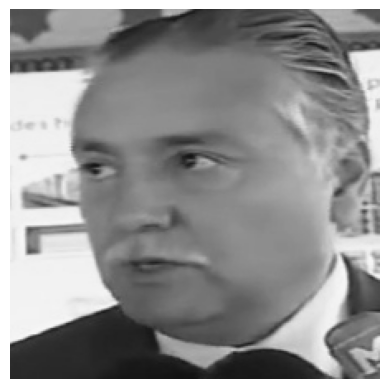

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numba import cuda

input_image = plt.imread('/content/original_027_47c60139_frame_000272.jpg')
height, width, channel = input_image.shape
# print(input_image.shape)
@cuda.jit
def grayscale(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    red = src[tidy, tidx, 0]
    green = src[tidy, tidx, 1]
    blue = src[tidy, tidx, 2]
    g = (red + green + blue)  / 3
    dst[tidy, tidx, 0] = dst[tidy, tidx, 1] = dst[tidy, tidx, 2] = g

devSrc = cuda.to_device(input_image)
devDst = cuda.device_array((height, width, 3), np.uint8)
gridSize = (8, 8)
blockSize = (32,32)
grayscale[gridSize, blockSize](devSrc, devDst)
hostDst = devDst.copy_to_host()
plt.imshow(hostDst)
plt.axis('off')
plt.show()